In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation, BatchNormalization, Input, Embedding, Dot, Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard, EarlyStopping

from wordcloud import WordCloud
%matplotlib inline

In [17]:
INPUT_DIR = os.path.join("..", "artifacts", "raw")

In [18]:
rading_df = pd.read_csv(INPUT_DIR+"/animelist.csv", low_memory=True, usecols=['user_id', 'anime_id', 'rating'])
rading_df.head()

,user_id,anime_id,rating
0,0,67,9
1,0,6702,7
2,0,242,10
3,0,4898,0
4,0,21,10


In [19]:
len(rading_df)

5000000

In [20]:
n_ratings = rading_df['user_id'].value_counts()

In [21]:
n_ratings

user_id
11100    14429
10255     8403
4773      5735
6852      5406
16057     5080
         ...  
16363        1
16377        1
16450        1
16465        1
16480        1
Name: count, Length: 15186, dtype: int64

In [22]:
rading_df = rading_df[rading_df['user_id'].isin(n_ratings[n_ratings>=400].index)].copy()


In [23]:
len(rading_df)

3246641

In [24]:
min_rating = min(rading_df['rating'])
min_rating

0

In [25]:
max_rating = max(rading_df['rating'])
max_rating

10

In [26]:
avg_rating = np.mean(rading_df['rating'])
avg_rating

np.float64(4.122732695114736)

In [27]:
rading_df['rating'] = rading_df['rating'].apply(lambda x : (min_rating)/(max_rating-min_rating)).values.astype(np.float64)

In [28]:
min_rating

0

In [29]:
max_rating

10

In [30]:
rading_df.duplicated().sum()

np.int64(0)

In [31]:
rading_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [32]:
user_ids = rading_df['user_id'].unique().tolist()
user2user_encoded = {x : i for i, x in enumerate(user_ids)}

In [33]:
user2user_encoded

{2: 0,
 6: 1,
 12: 2,
 16: 3,
 17: 4,
 19: 5,
 21: 6,
 41: 7,
 42: 8,
 44: 9,
 47: 10,
 53: 11,
 55: 12,
 60: 13,
 66: 14,
 73: 15,
 74: 16,
 85: 17,
 89: 18,
 90: 19,
 94: 20,
 98: 21,
 102: 22,
 108: 23,
 111: 24,
 112: 25,
 120: 26,
 121: 27,
 122: 28,
 135: 29,
 145: 30,
 146: 31,
 147: 32,
 153: 33,
 155: 34,
 156: 35,
 172: 36,
 174: 37,
 184: 38,
 190: 39,
 193: 40,
 194: 41,
 198: 42,
 204: 43,
 205: 44,
 209: 45,
 214: 46,
 219: 47,
 222: 48,
 227: 49,
 228: 50,
 235: 51,
 238: 52,
 240: 53,
 243: 54,
 248: 55,
 251: 56,
 252: 57,
 257: 58,
 264: 59,
 267: 60,
 272: 61,
 274: 62,
 275: 63,
 284: 64,
 285: 65,
 286: 66,
 290: 67,
 291: 68,
 293: 69,
 300: 70,
 301: 71,
 306: 72,
 308: 73,
 310: 74,
 313: 75,
 314: 76,
 316: 77,
 320: 78,
 321: 79,
 324: 80,
 325: 81,
 326: 82,
 327: 83,
 330: 84,
 336: 85,
 340: 86,
 345: 87,
 346: 88,
 349: 89,
 350: 90,
 366: 91,
 367: 92,
 371: 93,
 372: 94,
 375: 95,
 381: 96,
 382: 97,
 386: 98,
 389: 99,
 398: 100,
 405: 101,
 406: 102,
 

In [34]:
user2user_decoded = {i : x for i, x in enumerate(user_ids)}
user2user_decoded

{0: 2,
 1: 6,
 2: 12,
 3: 16,
 4: 17,
 5: 19,
 6: 21,
 7: 41,
 8: 42,
 9: 44,
 10: 47,
 11: 53,
 12: 55,
 13: 60,
 14: 66,
 15: 73,
 16: 74,
 17: 85,
 18: 89,
 19: 90,
 20: 94,
 21: 98,
 22: 102,
 23: 108,
 24: 111,
 25: 112,
 26: 120,
 27: 121,
 28: 122,
 29: 135,
 30: 145,
 31: 146,
 32: 147,
 33: 153,
 34: 155,
 35: 156,
 36: 172,
 37: 174,
 38: 184,
 39: 190,
 40: 193,
 41: 194,
 42: 198,
 43: 204,
 44: 205,
 45: 209,
 46: 214,
 47: 219,
 48: 222,
 49: 227,
 50: 228,
 51: 235,
 52: 238,
 53: 240,
 54: 243,
 55: 248,
 56: 251,
 57: 252,
 58: 257,
 59: 264,
 60: 267,
 61: 272,
 62: 274,
 63: 275,
 64: 284,
 65: 285,
 66: 286,
 67: 290,
 68: 291,
 69: 293,
 70: 300,
 71: 301,
 72: 306,
 73: 308,
 74: 310,
 75: 313,
 76: 314,
 77: 316,
 78: 320,
 79: 321,
 80: 324,
 81: 325,
 82: 326,
 83: 327,
 84: 330,
 85: 336,
 86: 340,
 87: 345,
 88: 346,
 89: 349,
 90: 350,
 91: 366,
 92: 367,
 93: 371,
 94: 372,
 95: 375,
 96: 381,
 97: 382,
 98: 386,
 99: 389,
 100: 398,
 101: 405,
 102: 406,
 

In [35]:
rading_df['users'] = rading_df['user_id'].map(user2user_encoded)
rading_df.head()

,user_id,anime_id,rating,users
213,2,24833,0.0,0
214,2,235,0.0,0
215,2,36721,0.0,0
216,2,40956,0.0,0
217,2,31933,0.0,0


In [36]:
n_users = len(user2user_encoded)
n_users

4203

In [37]:
anime_ids = rading_df['anime_id'].unique().tolist()
anime2anime_encoded = {x : i for i, x in enumerate(anime_ids)}
anime2anime_decoded = {i : x for i, x in enumerate(anime_ids)}
rading_df['anime'] = rading_df['anime_id'].map(anime2anime_encoded)

In [38]:
rading_df

,user_id,anime_id,rating,users,anime
213,2,24833,0.0,0,0
214,2,235,0.0,0,1
215,2,36721,0.0,0,2
216,2,40956,0.0,0,3
217,2,31933,0.0,0,4
...,...,...,...,...,...
4999916,16507,8985,0.0,4202,2533
4999917,16507,5454,0.0,4202,817
4999918,16507,15911,0.0,4202,2455
4999919,16507,878,0.0,4202,2154


In [39]:
n_anime = len(anime2anime_encoded)
n_anime

17149

In [40]:
rading_df = rading_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [41]:
rading_df.head()

,user_id,anime_id,rating,users,anime
0,13338,30,0.0,3405,688
1,15967,15583,0.0,4060,1518
2,4967,39586,0.0,1213,4963
3,4055,8039,0.0,997,4097
4,6170,30205,0.0,1552,1690


In [42]:
x = rading_df[['users', 'anime']].values
y = rading_df['rating']

In [43]:
test_size = 10000
train_indeces = rading_df.shape[0] - test_size

In [44]:
x_train, x_test, y_train, y_test = (
    x[:train_indeces], 
    x[train_indeces:],
    y[:train_indeces],
    y[train_indeces:]
)


In [45]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((3236641, 2), (10000, 2), (3236641,), (10000,))

In [46]:
type(x_train)

numpy.ndarray

In [47]:
x_train_array = [x_train[:, 0], x_train[:, 1]]
x_test_array = [x_test[:, 0], x_test[:, 1]]

In [48]:
type(x_test_array)

list

In [49]:
type(x_test_array[0])

numpy.ndarray

In [50]:
def recommendernet():
    embeddin_size = 128
    
    user = Input(name='user', shape=[1])
    user_embedding = Embedding(name='user_embedding', input_dim=n_users, output_dim=embeddin_size)(user)
    
    anime = Input(name='anime', shape=[1])
    anime_embeddding = Embedding(name='anime_embedding', input_dim=n_anime, output_dim=embeddin_size)(anime)
    
    x = Dot(name='dot_prodict', normalize=True, axes=2)([user_embedding, anime_embeddding])
    
    x = Flatten()(x)
    
    x = Dense(1, kernel_initializer='he_normal')(x)
    x= BatchNormalization()(x)
    x = Activation('sigmoid')(x)
    
    model = Model(inputs=[user, anime], outputs=x )
    model.compile(loss='binary_crossentropy', metrics=['mae', 'mse'], optimizer='Adam')
    
    return model
    

In [51]:
model = recommendernet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │    537,984 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime_embedding     │ (None, 1, 128)    │  2,195,072 │ anime[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_prodict (Dot)   │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ anime_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot_prodict[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1)         │          4 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,733,062 (10.43 MB)

 Trainable params: 2,733,060 (10.43 MB)

 Non-trainable params: 2 (8.00 B)

In [52]:
start_lr = 0.0001
min_lr = 0.0001
max_lr = 0.00005
batch_size = 10000

ramup_epchs = 5
sustain_epochs = 0
exp_decat = 0.8

In [53]:
def irfn(epoch):   #IT helps to find the best learining rate "Took from stack overflow..."
    if epoch < ramup_epchs:
        return (max_lr - start_lr) / ramup_epchs * epoch + start_lr
    
    elif epoch < ramup_epchs + sustain_epochs:
        return max_lr
    
    else:
        return (max_lr - min_lr) * exp_decat ** (epoch - ramup_epchs - sustain_epochs) + min_lr

In [54]:
lr_callback = LearningRateScheduler(lambda epoch : irfn(epoch), verbose=0)
checkpoint_filepath = './weights.weights.h5'

model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=True, monitor='val_loss', save_best_only=True)

early_stopping = EarlyStopping(patience=3, monitor='val_loss', mode='min', restore_best_weights=True)

In [55]:
my_call_back = [model_checkpoint, lr_callback, early_stopping]

In [56]:
history = model.fit(
    x=x_train_array,
    y=y_train,
    batch_size=batch_size,
    epochs=20,
    verbose=1,
    validation_data=(x_test_array, y_test),
    callbacks=my_call_back
)

Epoch 1/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - loss: 0.7893 - mae: 0.4966 - mse: 0.2874 - val_loss: 0.7099 - val_mae: 0.4915 - val_mse: 0.2573 - learning_rate: 1.0000e-04
Epoch 2/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 29s 88ms/step - loss: 0.7668 - mae: 0.4901 - mse: 0.2778 - val_loss: 0.7539 - val_mae: 0.4865 - val_mse: 0.2733 - learning_rate: 9.0000e-05
Epoch 3/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - loss: 0.7472 - mae: 0.4843 - mse: 0.2693 - val_loss: 0.7481 - val_mae: 0.4817 - val_mse: 0.2704 - learning_rate: 8.0000e-05
Epoch 4/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - loss: 0.7303 - mae: 0.4791 - mse: 0.2619 - val_loss: 0.7340 - val_mae: 0.4761 - val_mse: 0.2645 - learning_rate: 7.0000e-05


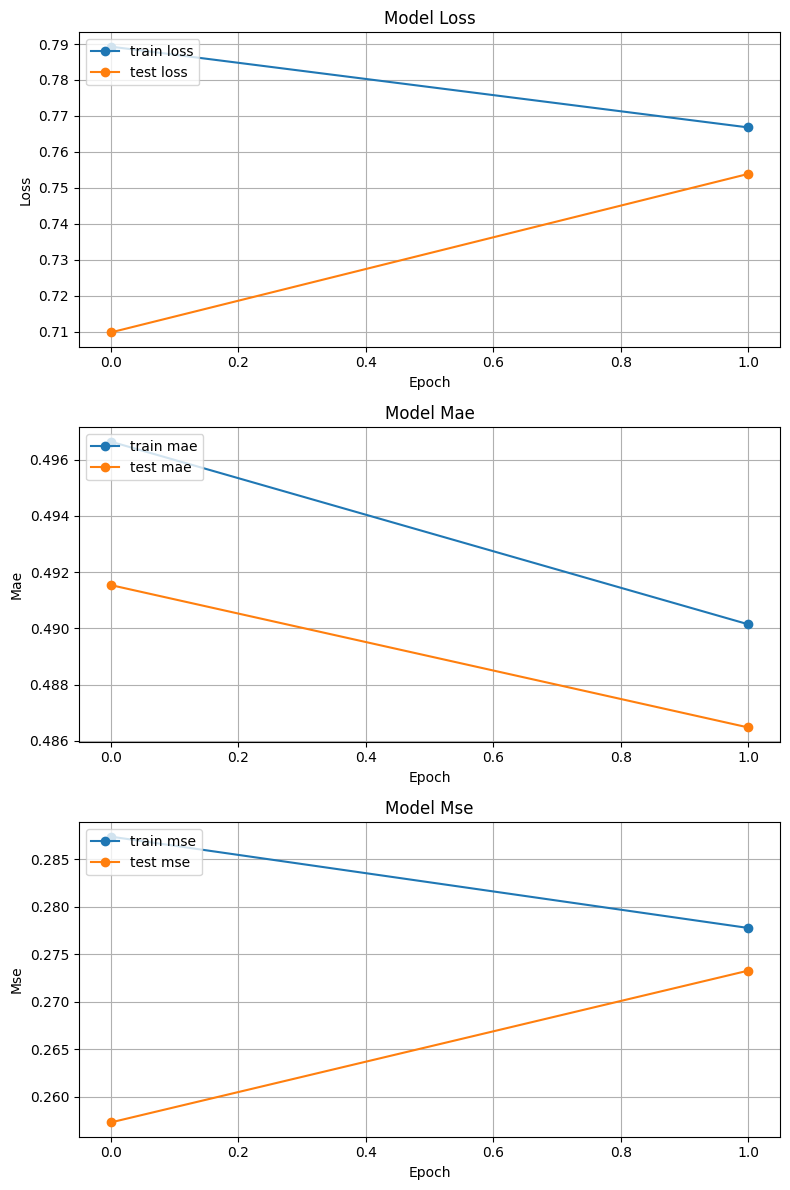

In [57]:
metrics = ["loss", "mae", "mse"]

# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 4))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history.history[metric][0:-2], marker="o", label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"][0:-2], marker="o", label=f"test {metric}")
    ax.set_title(f"Model {metric.capitalize()}")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper left")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def extract_weights(name, model):
    weights_layer = model.get_layer(name)
    weights = weights_layer.get_weights()[0]
    weights = weights / np.linalg.norm(weights,axis=1).reshape((-1, 1))
    
    
    
    return weights


In [59]:
anime_weights = extract_weights('anime_embedding', model)

In [61]:
user_weights = extract_weights('user_embedding', model)


Aime.csv

In [62]:
df = pd.read_csv(INPUT_DIR+'/anime.csv', low_memory=True)
df.head()

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,...,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,...,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0


In [63]:
df = df.replace('Unknown', np.nan)

In [64]:
def getAnime(anime_id):
    try:
        name = df[df.anime_id == anime_id].eng_version.values[0]
        if name is np.nan:
            name = df[df.anime_id == anime_id].Name.values[0]
        
    except:
        print('Error')
    return name

In [65]:
df['anime_id'] = df['MAL_ID']
df['eng_version'] = df['English name']
df['eng_version'] = df.anime_id.apply(lambda x : getAnime(x))


In [66]:
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",NaN,...,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0,5,Cowboy Bebop:The Movie


In [67]:
getAnime(6702)

'Fairy Tail'

In [68]:
df.sort_values(by=['Score'], inplace=True, ascending=False, kind='quicksort', na_position='last')

In [69]:
df.head(3)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
3971,5114,Fullmetal Alchemist: Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",Fullmetal Alchemist:Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,TV,64,"Apr 5, 2009 to Jul 4, 2010",Spring 2009,...,199160.0,70045.0,20210.0,9308.0,3222.0,1536.0,2162.0,16806.0,5114,Fullmetal Alchemist:Brotherhood
15926,40028,Shingeki no Kyojin: The Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",Attack on Titan Final Season,進撃の巨人 The Final Season,TV,16,"Dec 7, 2020 to ?",Winter 2021,...,26016.0,8793.0,2674.0,1336.0,588.0,382.0,514.0,11061.0,40028,Attack on Titan Final Season
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",Steins;Gate,STEINS;GATE,TV,24,"Apr 6, 2011 to Sep 14, 2011",Spring 2011,...,140914.0,57740.0,21375.0,11126.0,5061.0,2292.0,1678.0,5255.0,9253,Steins;Gate


In [70]:
df.columns, len(df.columns)

(Index(['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name',
        'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors',
        'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity',
        'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped',
        'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6',
        'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1', 'anime_id',
        'eng_version'],
       dtype='str'),
 37)

In [71]:
df[['anime_id', 'eng_version', 'Score', 'Genres', 'Episodes', 'Premiered', 'Type', 'Members']]

,anime_id,eng_version,Score,Genres,Episodes,Premiered,Type,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",64,Spring 2009,TV,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,Winter 2021,TV,733260
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,Spring 2011,TV,1771162
14963,38524,Attack on Titan Season 3 Part 2,9.1,"Action, Drama, Fantasy, Military, Mystery, Sho...",10,Spring 2019,TV,1073626
9913,28977,Gintama Season 4,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",51,Spring 2015,TV,404121
...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,NaN,"Adventure, Mystery, Supernatural",NaN,NaN,ONA,354
17558,48483,Mieruko-chan,NaN,"Comedy, Horror, Supernatural",NaN,NaN,TV,7010
17559,48488,Higurashi:When They Cry – SOTSU,NaN,"Mystery, Dementia, Horror, Psychological, Supe...",NaN,Summer 2021,TV,11309
17560,48491,Yama no Susume: Next Summit,NaN,"Adventure, Slice of Life, Comedy",NaN,NaN,TV,1386


In [72]:
def getAnimeFeame(anime, df):
    if isinstance(anime, int):
        return df[df.anime_id == anime]
    
    if isinstance(anime, str):
        return df[df.eng_version == anime]
    

In [73]:
getAnimeFeame(48491, df)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
17560,48491,Yama no Susume: Next Summit,NaN,"Adventure, Slice of Life, Comedy",NaN,ヤマノススメ Next Summit,TV,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48491,Yama no Susume: Next Summit


In [74]:
getAnimeFeame('Gintama Season 4', df)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
9913,28977,Gintama°,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",Gintama Season 4,銀魂°,TV,51,"Apr 8, 2015 to Mar 30, 2016",Spring 2015,...,21360.0,10215.0,3898.0,2311.0,952.0,648.0,1100.0,4508.0,28977,Gintama Season 4


### Aime with synopsis csv

In [75]:
col = ['MAL_ID', 'Name', 'Genres', 'sypnopsis']

In [76]:
synopsis_df = pd.read_csv(INPUT_DIR+'/anime_with_synopsis.csv', usecols=col)

In [77]:
synopsis_df.head()

,MAL_ID,Name,Genres,sypnopsis
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,7,Witch Hunter Robin,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,8,Bouken Ou Beet,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...


In [78]:
def getSynopsis(anime, df):
    if isinstance(anime, int):
        return synopsis_df[synopsis_df.MAL_ID == anime].sypnopsis.values[0]

    if isinstance(anime, str):
        return synopsis_df[synopsis_df.Name == anime].sypnopsis.values[0]
    
    

In [79]:
getSynopsis(38524, df)

'Seeking to restore humanity\'s diminishing hope, the Survey Corps embark on a mission to retake Wall Maria, where the battle against the merciless "Titans" takes the stage once again. Returning to the tattered Shiganshina District that was once his home, Eren Yeager and the Corps find the town oddly unoccupied by Titans. Even after the outer gate is plugged, they strangely encounter no opposition. The mission progresses smoothly until Armin Arlert, highly suspicious of the enemy\'s absence, discovers distressing signs of a potential scheme against them. Shingeki no Kyojin Season 3 Part 2 follows Eren as he vows to take back everything that was once his. Alongside him, the Survey Corps strive—through countless sacrifices—to carve a path towards victory and uncover the secrets locked away in the Yeager family\'s basement.'

In [80]:
getSynopsis('One Piece', df)

'Gol D. Roger was known as the "Pirate King," the strongest and most infamous being to have sailed the Grand Line. The capture and execution of Roger by the World Government brought a change throughout the world. His last words before his death revealed the existence of the greatest treasure in the world, One Piece. It was this revelation that brought about the Grand Age of Pirates, men who dreamed of finding One Piece—which promises an unlimited amount of riches and fame—and quite possibly the pinnacle of glory and the title of the Pirate King. Enter Monkey D. Luffy, a 17-year-old boy who defies your standard definition of a pirate. Rather than the popular persona of a wicked, hardened, toothless pirate ransacking villages for fun, Luffy\'s reason for being a pirate is one of pure wonder: the thought of an exciting adventure that leads him to intriguing people and ultimately, the promised treasure. Following in the footsteps of his childhood hero, Luffy and his crew travel across the 

### Content Based Recommendation


In [81]:
pd.set_option('max_colwidth', None)

In [86]:
# def find_similiar_animes(name, anime_weights, anime2anime_encoded, anime2anime_decoded,
#                          df, synopsis_df, n=10, return_dist=False, neg=False):
    
#     try:
#         index = getAnimeFeame(name, df).anime_id.value[0]
#         encoded_index = anime2anime_encoded.get(index)
#         weights = anime_weights

#         dist = np.dot(weights, weights[encoded_index])
#         sorted_dists = np.argsort(dict)
        
#         n = n+1
        
#         if neg:
#             closest = sorted_dists[:n]
#         else:
#             closest = sorted_dists[-n:]
        
#         print(f'Anime closest {name}')
        
#         if return_dist:
#             return dist, closest
        
#         SimilarityArr = []
        
#         for close in closest:
#             decoded_id = anime2anime_decoded.get(close)
            
#             synopsis = getSynopsis(decoded_id, df)
            
#             anime_frame = getAnimeFeame(decoded_id, df)
            
#             anime_name = anime_frame.eng_version.values[0]
#             genre = anime_frame.Genres.values[0]
#             Similarity = dist[close]
            
#             SimilarityArr.append({
#                 'anime_id' : decoded_id,
#                 'name' : anime_name, 
#                 'similarity' : Similarity,
#                 'genre' : genre,
#                 'sysnopsis' : synopsis
#                 })
        
#         frame = pd.DataFrame(SimilarityArr).sort_index(by='similarity', ascending=False)
#         return frame[frame.anime_id != index].drop(['anime_id'], axis=1)

#     except:
#         print('Error')    
    
    
def find_similar_animes(name, anime_weights, anime2anime_encoded, anime2anime_decoded, df, synopsis_df, n=10, return_dist=False, neg=False):
    # Get the anime_id for the given name
    index = getAnimeFeame(name, df).anime_id.values[0]
    encoded_index = anime2anime_encoded.get(index)

    if encoded_index is None:
        raise ValueError(f"Encoded index not found for anime ID: {index}")

    weights = anime_weights

    # Compute the similarity distances
    dists = np.dot(weights, weights[encoded_index])  # Ensure weights[encoded_index] is a 1D array
    sorted_dists = np.argsort(dists)

    n = n + 1

    # Select closest or farthest based on 'neg' flag
    if neg:
        closest = sorted_dists[:n]
    else:
        closest = sorted_dists[-n:]

    # Return distances and closest indices if requested
    if return_dist:
        return dists, closest

    # Build the similarity array
    SimilarityArr = []
    for close in closest:
        decoded_id = anime2anime_decoded.get(close)
       

       
        anime_frame = getAnimeFeame(decoded_id, df)

        anime_name = anime_frame.eng_version.values[0]
        genre = anime_frame.Genres.values[0]
        similarity = dists[close]
   

        SimilarityArr.append({
            "anime_id": decoded_id,
            "name": anime_name,
            "similarity": similarity,
            "genre": genre,
        })
       

    # Create a DataFrame with results and sort by similarity
    Frame = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)
    return Frame[Frame.anime_id != index].drop(['anime_id'], axis=1)


In [90]:
find_similar_animes(
    "Naruto",
    anime_weights,
    anime2anime_encoded,
    anime2anime_decoded,
    df,
    synopsis_df
)

,name,similarity,genre
9,Terror in Resonance,0.381056,"Mystery, Psychological, Thriller"
8,Nanairo Kakumei,0.308057,"Comedy, School, Shoujo"
7,Karasu no Panya-san/Dorobou Gakkou,0.302426,Kids
6,House of Five Leaves,0.302379,"Mystery, Historical, Drama, Samurai, Seinen"
5,Neko Matsuri,0.301602,Music
4,Aoi Kokuhaku,0.299156,Hentai
3,I want to eat your pancreas,0.293760,Drama
2,"Boku no Imouto wa ""Osaka Okan""",0.290241,Comedy
1,Ring ni Kakero 1 Episode:The Pacific War,0.285035,"Action, Sports, Shounen"
0,Nazotoki-hime wa Meitantei♥,0.284895,"Mystery, Shoujo"
